# PGD-атака на нейросетевой кодек изображений Cheng2020

Задание предложено Владимиром Мазиным, AIRI, Safe AI.

## Постановка

**Цель работы** — реализовать состязательную атаку Projected Gradient Descent (PGD) на нейросетевой кодек `cheng2020_attn` из библиотеки `compressai` и изучить её влияние на качество сжатия. В отличие от JPEG AI, этот кодек показывает неустойчивость к PGD, так что хорошо подходит для демонстрации атаки.

PGD состоит в том, чтобы добавить к изображению `x` невидимый шум `δ` так, чтобы сжатое состязательное изображение `C(x+δ)` сильно отличалось от `C(x)`.

$$\delta^* = \arg\max_{\|\delta\|_\infty \leq \varepsilon} \text{MSE}(C(x),\, C(x + \delta))$$

## Метрики

Метрикой качества восстановления выберем `PSNR` (Peak Signal-to-Noise Ratio), дБ:

$$
\mathrm{PSNR} = 10\log_{10}\left(\frac{1}{\mathrm{MSE(x-\hat{x})}}\right)
$$

Чем PSNR выше, тем лучше. Данная метрика детерминирована, хотя не отражает восприятие изображения человеческим глазом.

Также будем вычислять битрейт `BPP` (Bits Per Pixel):

$$
\mathrm{BPP} = - \frac{1}{HW}\sum \log_2(p)
$$

## 0. Установка зависимостей

In [ ]:
!pip install compressai Pillow matplotlib torch torchvision requests scikit-image

## 1. Импорты

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
from io import BytesIO
from PIL import Image

import compressai
from compressai.zoo import cheng2020_attn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


## 2. Загрузка модели

Загрузим предобученную модель `cheng2020_attn` (quality=3). Это нейросетевой кодек изображений из статьи [Cheng et al., 2020]. Переводим в режим `eval` и отправляем на `DEVICE`.

In [3]:
model = cheng2020_attn(quality=3, pretrained=True)

for p in model.parameters():
    p.requires_grad_(False)

model = model.eval()
model = model.to(DEVICE)

## 3. Загрузка изображения

Загружаем известное изображение Kodak с попугаями.

In [20]:
def load_image(size_mult: int = 64) -> torch.Tensor:
    """Возвращает тестовое изображение [1, 3, H, W] в [0, 1]."""
    import requests
    url = "https://r0k.us/graphics/kodak/kodak/kodim23.png"
    r = requests.get(url, timeout=10)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content)).convert("RGB")

    w, h = img.size
    img = img.crop((0, 0, w - w % size_mult, h - h % size_mult))
    x = torch.from_numpy(np.array(img)).float() / 255.0  # HWC, [0,1]
    x = x.permute(2, 0, 1).unsqueeze(0)                  # [1, 3, H, W]
    return x.to(DEVICE)

x = load_image()
print(f"Image tensor shape: {x.shape}, min={x.min():.2f}, max={x.max():.2f}")

Image tensor shape: torch.Size([1, 3, 512, 768]), min=0.00, max=1.00


## 4. Вспомогательные функции

In [5]:
def compress_and_decode(model: torch.nn.Module, x: torch.Tensor) -> dict:
    """
    Прямой проход через кодек. Даёт x_hat — сжатую версию изображения
    и битрейт.
    """
    model.eval()
    with torch.no_grad():
        out = model(x)
        x_hat = out["x_hat"].clamp(0, 1)
        num_pixels = x.shape[-1] * x.shape[-2]
        bpp = sum(
            (-torch.log2(lk).sum() / num_pixels).item()
            for lk in out["likelihoods"].values()
        )
    return {"x_hat": x_hat, "bpp": bpp}


def psnr(original: torch.Tensor, reconstructed: torch.Tensor) -> float:
    """Вычисляет PSNR в дБ между двумя тензорами [0,1]."""
    mse = F.mse_loss(original, reconstructed).item()
    if mse == 0:
        return float("inf")
    return 10 * math.log10(1.0 / mse)


def to_numpy(t: torch.Tensor) -> np.ndarray:
    """Тензор [1,3,H,W] → numpy HWC uint8."""
    return (t.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

## 5. Базовые метрики (без атаки)

Прежде чем атаковать, получим метрики для исходного изображения `x`.

In [11]:
result_clean = compress_and_decode(model, x)
x_hat_clean = result_clean["x_hat"]
bpp_clean = result_clean["bpp"]
psnr_clean = psnr(x, x_hat_clean)

print(f"Baseline — PSNR: {psnr_clean:.2f} dB  |  BPP: {bpp_clean:.4f}")

Baseline — PSNR: 34.74 dB  |  BPP: 0.1146


В среднем на пиксель 0.11 бита, качетсов PSNR в диапазоне от 30 до 35 дБ считается приятным глазу.

## 6. PGD-атака

Если считать градиент через `model(x_adv)` в режиме `model.eval()`, квантование внутри кодека выполняется округлением `torch.round`, что может занулить возмущение. `x_adv.grad` будет нулевым, и атака ничего не изменит (`ΔPSNR = 0`). На время атаки модель переводят в `model.train()` — там квантование заменяется
добавлением шума и становится дифференцируемым.

In [9]:
def pgd_attack(
    model: torch.nn.Module,
    x: torch.Tensor,
    x_hat_clean: torch.Tensor,
    epsilon: float = 8 / 255,
    alpha: float = 2 / 255,
    iters: int = 10,
    seed: int = 0,
) -> torch.Tensor:
    """
    PGD-атака на нейрокодек.

    x           : исходное изображение [1,3,H,W] в [0,1]
    x_hat_clean : C(x) — сжатое исходное изображение (целевой эталон)
    epsilon     : максимальная ∞-норма пертурбации
    alpha       : размер шага
    iters       : число итераций
    """
    torch.manual_seed(seed)
    was_training = model.training
    model.train()

    x_adv = x.clone().detach()
    for i in range(iters):
        x_adv.requires_grad_(True)

        # дифференцируемый прямой проход через кодек
        x_hat_adv = model(x_adv)["x_hat"].clamp(0, 1)

        # gradient ascent
        loss = -F.mse_loss(x_hat_clean, x_hat_adv)
        loss.backward()

        with torch.no_grad():
            # шаг атаки
            x_adv = x_adv - alpha * x_adv.grad.sign()
            # проекция в eps-шар вокруг x
            x_adv = torch.max(torch.min(x_adv, x + epsilon), x - epsilon)
            x_adv = x_adv.clamp(0, 1)

        x_adv = x_adv.detach()

        if (i + 1) % 1 == 0:
            with torch.no_grad():
                cur = F.mse_loss(x_hat_clean, x_hat_adv).item()
            print(f"  Iter {i+1:3d}/{iters} | MSE(C(x), C(x_adv)): {cur:.6f}")

    if not was_training:
        model.eval()
    return x_adv.detach()

За один проход увеличили MSE на порядок.

In [10]:
print("Запускаем PGD-атаку...")
x_adv = pgd_attack(
    model, x, x_hat_clean,
    epsilon=8/255,
    alpha=2/255,
    iters=10
)

Запускаем PGD-атаку...
  Iter   1/10 | MSE(C(x), C(x_adv)): 0.000194
  Iter   2/10 | MSE(C(x), C(x_adv)): 0.000288
  Iter   3/10 | MSE(C(x), C(x_adv)): 0.000455
  Iter   4/10 | MSE(C(x), C(x_adv)): 0.000725
  Iter   5/10 | MSE(C(x), C(x_adv)): 0.001096
  Iter   6/10 | MSE(C(x), C(x_adv)): 0.001229
  Iter   7/10 | MSE(C(x), C(x_adv)): 0.001366
  Iter   8/10 | MSE(C(x), C(x_adv)): 0.001399
  Iter   9/10 | MSE(C(x), C(x_adv)): 0.001452
  Iter  10/10 | MSE(C(x), C(x_adv)): 0.001480


## 7. Оценка результатов

Посчитаем метрики на сжатом изображении. PSNR значительно снижен, BPP вырос, потому что на изображении стало больше деталей для кодирования:

| Metric | PSNR (dB) | BPP |
|---|---|---|
| Baseline $C(x)$ | 34.74 | 0.1146 |
| После атаки $C(x_{adv})$ | 29.70 | 0.1838 |
| Delta | -5.04 | 0.0693 |


In [12]:

result_adv = compress_and_decode(model, x_adv)
x_hat_adv = result_adv["x_hat"]
bpp_adv = result_adv["bpp"]
psnr_adv = psnr(x, x_hat_adv)

print(f"{'':30s} {'PSNR (dB)':>12} {'BPP':>10}")
print("-" * 55)
print(f"{'Baseline C(x)':30s} {psnr_clean:12.2f} {bpp_clean:10.4f}")
print(f"{'После атаки C(x_adv)':30s} {psnr_adv:12.2f} {bpp_adv:10.4f}")
print("-" * 55)
print(f"{'Delta':30s} {psnr_adv - psnr_clean:12.2f} {bpp_adv - bpp_clean:10.4f}")

                                  PSNR (dB)        BPP
-------------------------------------------------------
Baseline C(x)                         34.74     0.1146
После атаки C(x_adv)                  29.70     0.1838
-------------------------------------------------------
Delta                                 -5.04     0.0693


## 8. Визуализация

Выведем полученные изображения и карту шумов.

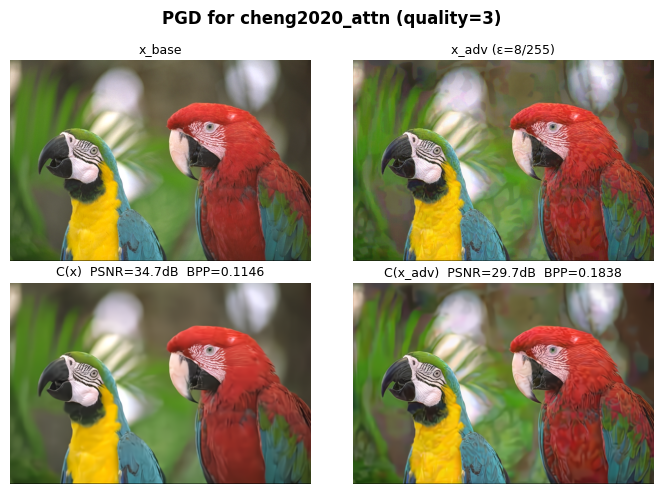

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5))

axes[0, 0].imshow(to_numpy(x))
axes[0, 1].imshow(to_numpy(x_adv))
axes[1, 0].imshow(to_numpy(x_hat_clean))
axes[1, 1].imshow(to_numpy(x_hat_adv))

titles = [
    "x_base",
    f"x_adv (ε={8}/255)",
    f"C(x)  PSNR={psnr_clean:.1f}dB  BPP={bpp_clean:.4f}",
    f"C(x_adv)  PSNR={psnr_adv:.1f}dB  BPP={bpp_adv:.4f}",
]
for ax, title in zip(axes.flat, titles):
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("PGD for cheng2020_attn (quality=3)", fontweight="bold")
plt.tight_layout()
plt.savefig("pgd_attack_result_2x2.png", dpi=120, bbox_inches="tight")
plt.show()

По карте шумов видно, что возмущения сосредоточены в семантически важных высокочастотных зонах: области перьев, глаз попугаев, на границах.

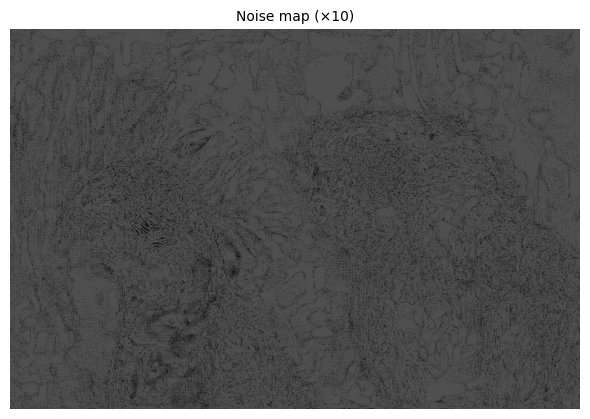

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
noise_map = ((x_adv - x).abs().mean(dim=1, keepdim=True) * 10).clamp(0, 1)
ax.imshow(to_numpy(noise_map.repeat(1, 3, 1, 1)))
ax.set_title("Noise map (×10)", fontsize=10)
ax.axis("off")

plt.tight_layout()
plt.savefig("pgd_attack_noise_map.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Зависимость метрик от числа шагов

Фиксируем $\epsilon$ и $\alpha$. Для чистоты эксперимента для каждого шага проводим независимые атаки, а не смотрим на разные шаги одной.

In [ ]:
iters_list = list(range(0, 31))

mse_list = []
psnr_list = []
bpp_list = []

for n_iters in iters_list:
    x_adv_i = pgd_attack(
        model, x, x_hat_clean,
        epsilon=8/255,
        alpha=2/255,
        iters=n_iters,
        seed=0
    )
    result_i = compress_and_decode(model, x_adv_i)
    x_hat_i = result_i["x_hat"]

    mse_list.append(F.mse_loss(x_hat_clean, x_hat_i).item())
    psnr_list.append(psnr(x, x_hat_i))
    bpp_list.append(result_i["bpp"])

Построим графики.

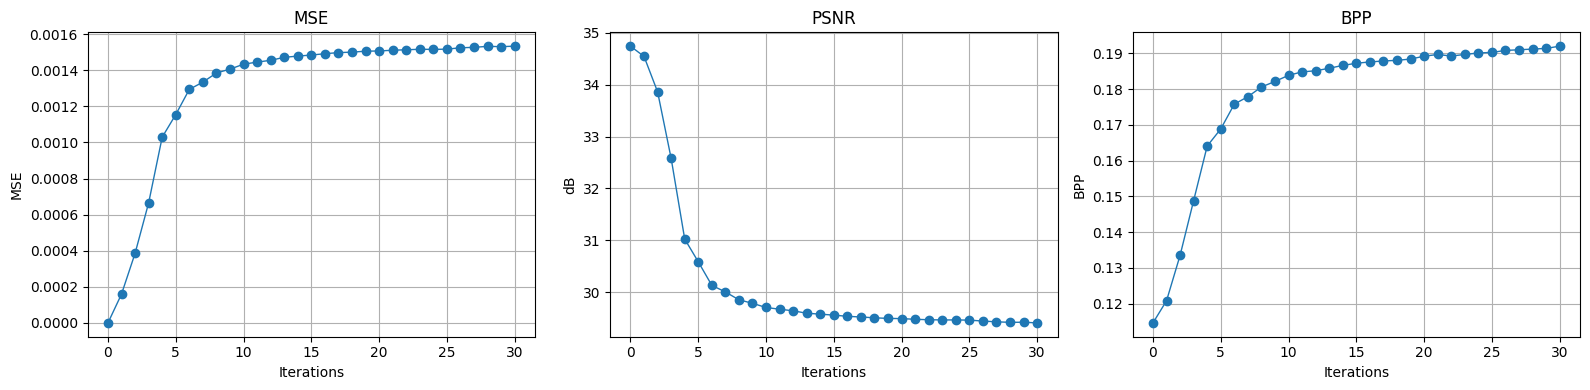

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(iters_list, mse_list, marker="o", linewidth=1)
axes[0].set_title("MSE")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE")
axes[0].grid(True)

axes[1].plot(iters_list, psnr_list, marker="o", linewidth=1)
axes[1].set_title("PSNR")
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("dB")
axes[1].grid(True)

axes[2].plot(iters_list, bpp_list, marker="o", linewidth=1)
axes[2].set_title("BPP")
axes[2].set_xlabel("Iterations")
axes[2].set_ylabel("BPP")
axes[2].grid(True)

plt.tight_layout()
plt.show()

Сходимость означает, что мы достигли предельных возможностей атаки в рамках заданного $\epsilon$-шара.

| MSE | PSNR | BPP |
|---|---|---|
| 0.00000 | 34.74 dB | 0.1146 |
| 0.00154 | 29.41 dB | 0.1918 |

